In [23]:
# imports

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [24]:
# choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
# creating batches
BATCH_SIZE = 128

# convert image to tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

# train dataset/dataloader
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [26]:
# coding VAE class

latent_dim = 128

class VAE(nn.Module):
    def __init__(self, input_dim = 784, hidden_dim = 256, latent_dim = latent_dim):
        super(VAE, self).__init__()

        # encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        # we do logvar here, bcuz log(sigma^2) can be negative or positive, but sigma^2 itself can only be positive.
        # so if we didn't do log(variance), then we'd have to force positive output.
        # so, instead we just predict log(sigma^2), then do exp(log(sigma^2)) = sigma^2
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

        # other layers, NOTE: we didn't use nn.Sequential here, so we're just defining layers
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encoder(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar) # gives us sigma
        eps = torch.randn_like(std)
        # randn_like function ::
        # Create a tensor with the same shape as std, where each entry is
        # sampled independently from a standard normal distribution.

        z = mu + eps * std
        return z

    def decoder(self, z):
        h = self.relu(self.fc2(z))
        x_hat = self.sigmoid(self.fc3(h))
        return x_hat

    def forward(self, x):
      mu, logvar = self.encoder(x)
      z = self.reparameterize(mu, logvar) # sampled z
      x_hat = self.decoder(z)
      return x_hat, mu, logvar

In [27]:
# define loss
def vae_loss(x, x_hat, mu, logvar):
    # calling functional allows you to compute the loss directly, it's an API style call.
    # reconstruction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    reconstruction_loss = nn.functional.mse_loss(x_hat, x, reduction='sum')

    ### important concept:
    # reduction="none"  → keep every individual error
    # reduction="sum"   → add all errors together
    # reduction="mean"  → average all errors
    ###


    # this comes from directly summing over equation KL, where true/reference distribution P is N(0, 1) &
    # other distribution Q is N(mu, sigma^2)
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return reconstruction_loss + kl_divergence

In [28]:
# initialize model and optimizer
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [29]:
# train loop
epochs = 15

model.train()

for epoch in range(epochs):
    train_loss = 0
    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)
        optimizer.zero_grad()
        x_hat, mu, logvar = model(x)
        loss = vae_loss(x, x_hat, mu, logvar)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.6f}")

Epoch 1/15, Train Loss: 51.297826
Epoch 2/15, Train Loss: 40.913987
Epoch 3/15, Train Loss: 37.896254
Epoch 4/15, Train Loss: 35.425092
Epoch 5/15, Train Loss: 34.027180
Epoch 6/15, Train Loss: 33.212785
Epoch 7/15, Train Loss: 32.592792
Epoch 8/15, Train Loss: 32.161644
Epoch 9/15, Train Loss: 31.830901
Epoch 10/15, Train Loss: 31.594730
Epoch 11/15, Train Loss: 31.403434
Epoch 12/15, Train Loss: 31.222410
Epoch 13/15, Train Loss: 31.105163
Epoch 14/15, Train Loss: 30.995025
Epoch 15/15, Train Loss: 30.853731


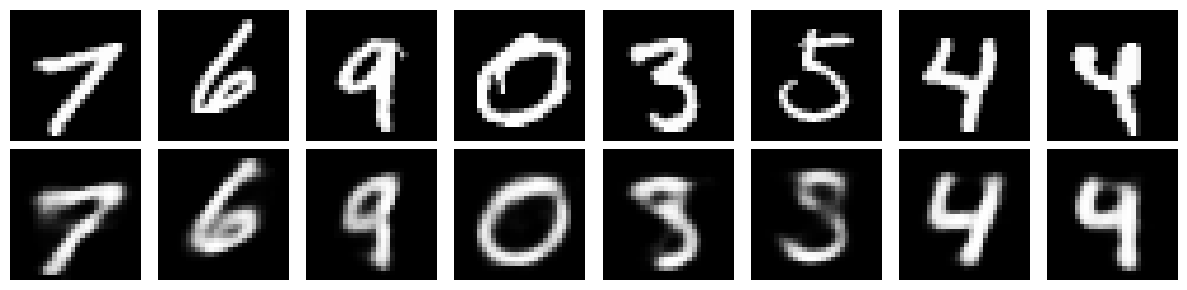

In [30]:
model.eval()

with torch.no_grad():
    # Grab one batch
    x, _ = next(iter(train_loader))

    # [128, 1, 28, 28] -> [128, 784]
    x = x.view(-1, 784).to(device)

    # VAE forward pass
    x_recon, mu, logvar = model(x)

    n = 8
    plt.figure(figsize=(12, 3))

    for i in range(n):
        # Top row: original
        plt.subplot(2, n, i + 1)
        plt.imshow(x[i].view(28, 28).cpu(), cmap="gray")
        plt.axis("off")

        # Bottom row: reconstruction
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(x_recon[i].view(28, 28).cpu(), cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

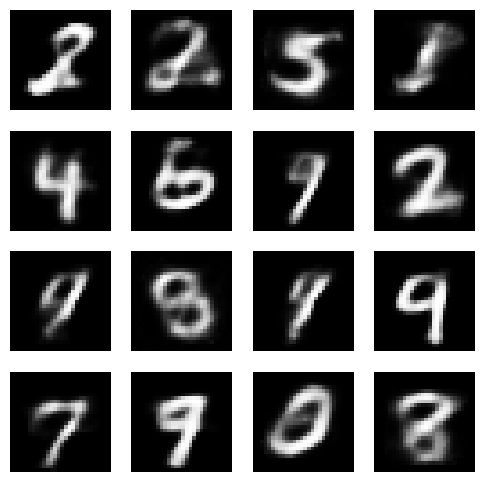

In [31]:
# trying random sampled
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = model.decoder(z).cpu()

plt.figure(figsize=(6, 6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(samples[i].view(28, 28), cmap="gray")
    plt.axis("off")

plt.show()